<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/low_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Time Series Analysis on Hindustan Copper Stock Data

This notebook will perform a time series analysis on the historical 'low' stock price of Hindustan Copper using an ARIMA model. The process involves:

1.  Loading and preprocessing the data.
2.  Splitting data into training and testing sets.
3.  Automatically selecting the best ARIMA model order.
4.  Applying walk-forward validation for predictions.
5.  Calculating and displaying the Root Mean Squared Error (RMSE).
6.  Visualizing the actual vs. predicted values.
7.  Providing a detailed listing of expected vs. predicted 'low' prices for the test set.

In [ ]:
# Install necessary libraries
!pip install pmdarima openpyxl odfpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


### 1. Data Loading and Preprocessing

We will load the `hindustan_copper.ods` file, parse the 'Date' column as datetime, set it as the index, sort the data by date, and then resample to business day frequency, forward-filling any missing values. Finally, we'll extract the 'low' column as our target series for forecasting.

In [ ]:
import pandas as pd

# Define the path to your .ods file
file_path = '/content/Hindustan_copper.ods'  # Corrected filename: 'Hindustan_copper.ods'

# Load the data using pd.read_excel with engine='odf'
# Assuming the datetime column is named 'Date' and the target column is 'low'
try:
    df = pd.read_excel(file_path, engine='odf')
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded to /content.")
    raise
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}")
    raise

# Parse the datetime column and set it as index
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.set_index('datetime')

# Sort the index to ensure chronological order
df = df.sort_index()

# Assign business day frequency and forward-fill any missing values
target_series = df['low'].asfreq('B', method='ffill')

print("Original DataFrame head:")
display(df.head())
print("\nTarget Series (Low Price) head after preprocessing:")
display(target_series.head())
print(f"Data loaded and preprocessed. Total observations: {len(target_series)}")

Original DataFrame head:


,symbol,open,high,low,close,volume
datetime,,,,,,
2016-01-04 00:00:00+05:30,HINDALCO,84.20,85.90,80.4,80.75,8706224
2016-01-05 00:00:00+05:30,HINDALCO,82.00,83.95,80.6,82.60,9819068
2016-01-06 00:00:00+05:30,HINDALCO,82.40,82.85,79.7,80.55,6494446
2016-01-07 00:00:00+05:30,HINDALCO,79.00,79.40,76.1,76.65,8098318
2016-01-08 00:00:00+05:30,HINDALCO,77.45,78.15,75.2,76.90,6800939



Target Series (Low Price) head after preprocessing:


,low
datetime,
2016-01-04 00:00:00+05:30,80.4
2016-01-05 00:00:00+05:30,80.6
2016-01-06 00:00:00+05:30,79.7
2016-01-07 00:00:00+05:30,76.1
2016-01-08 00:00:00+05:30,75.2


Data loaded and preprocessed. Total observations: 2671


### 2. Data Splitting and ARIMA Model Selection

The data will be split into an 80% training set and a 20% testing set, maintaining the time order. We will then use `auto_arima` from `pmdarima` to automatically determine the optimal (p,d,q) order for our ARIMA model based on the training data.

In [ ]:
from pmdarima import auto_arima

# Split data into training and testing sets (80% train, 20% test)
train_size = int(len(target_series) * 0.8)
train, test = target_series[0:train_size], target_series[train_size:]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

# Find the best ARIMA order using auto_arima
print("\nFinding best ARIMA order using auto_arima...")
model_arima = auto_arima(train, seasonal=False, stepwise=True,
                         suppress_warnings=True, error_action='ignore')
order = model_arima.order

print(f"Best ARIMA order found: {order}")

Train set size: 2136
Test set size: 535

Finding best ARIMA order using auto_arima...
Best ARIMA order found: (0, 1, 2)


### 3. Walk-Forward Validation and Prediction

We will perform walk-forward validation. For each point in the test set, the ARIMA model will be retrained on all data available up to that point (training data plus previous actual test values). It will then predict one step ahead. The actual value will be added to the history for the next iteration.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

history = [x for x in train]
predictions = list()

print("\nStarting walk-forward validation...")
for t in range(len(test)):
    # Train ARIMA model on the current history
    model = ARIMA(history, order=order)
    model_fit = model.fit()

    # Predict 1 step ahead
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat)

    # Get the actual observation and append to history
    obs = test.iloc[t]
    history.append(obs)

    if (t + 1) % 50 == 0 or t == len(test) - 1:
        print(f'Step {t+1}/{len(test)}: Predicted={yhat:.2f}, Expected={obs:.2f}')

# Convert predictions list to a pandas Series with the test set's index
predictions_series = pd.Series(predictions, index=test.index)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, predictions_series))
print(f'\nFinal ARIMA Order: {order}')
print(f'Root Mean Squared Error (RMSE): {rmse:.3f}')

# Create a DataFrame for expected vs. predicted listing
results_df = pd.DataFrame({'Expected_Low': test, 'Predicted_Low': predictions_series})
print("\nExpected vs Predicted (Low Price) for Test Set:")
display(results_df.head())
print(f"Total test predictions: {len(results_df)}")


Starting walk-forward validation...
Step 50/535: Predicted=651.30, Expected=657.50
Step 100/535: Predicted=657.44, Expected=665.00
Step 150/535: Predicted=739.78, Expected=722.50
Step 200/535: Predicted=647.66, Expected=652.05
Step 250/535: Predicted=637.47, Expected=636.25
Step 300/535: Predicted=622.26, Expected=629.55
Step 350/535: Predicted=660.21, Expected=665.00
Step 400/535: Predicted=739.60, Expected=741.55
Step 450/535: Predicted=807.18, Expected=808.20
Step 500/535: Predicted=924.42, Expected=948.30
Step 535/535: Predicted=854.29, Expected=876.00

Final ARIMA Order: (0, 1, 2)
Root Mean Squared Error (RMSE): 13.318

Expected vs Predicted (Low Price) for Test Set:


,Expected_Low,Predicted_Low
datetime,,
2024-03-12 00:00:00+05:30,525.3,532.471822
2024-03-13 00:00:00+05:30,501.2,524.544019
2024-03-14 00:00:00+05:30,507.0,499.392335
2024-03-15 00:00:00+05:30,517.5,508.557077
2024-03-18 00:00:00+05:30,527.0,517.972596


Total test predictions: 535


### 4. Visualization of Results

Two plots will be generated:

*   **Full Dataset View**: Shows the entire dataset, including the training period, the test period's actual values, and the predicted values for the test period. A vertical line indicates the train/test split.
*   **Zoomed Test View**: Focuses solely on the test period, comparing actual and predicted values. A vertical line marks the start of the test set.

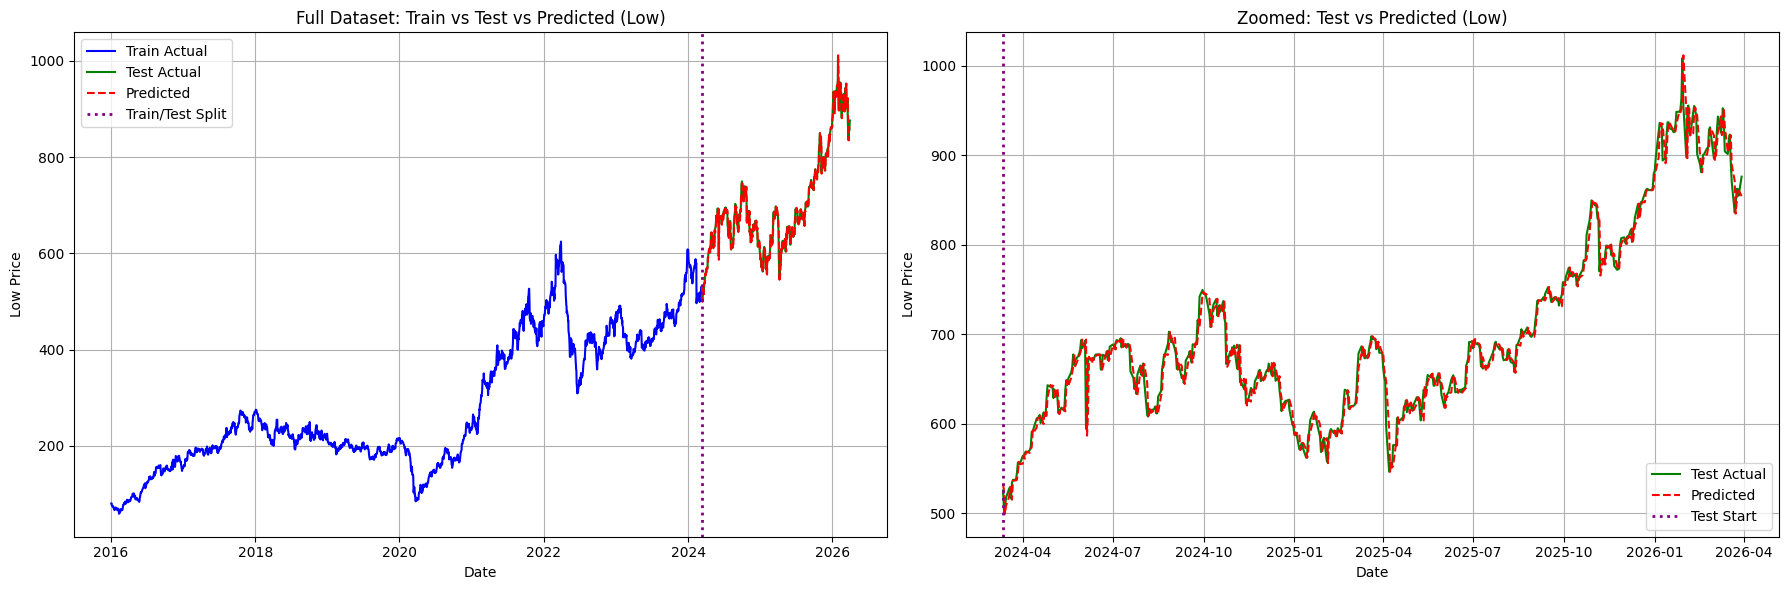

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

# Left subplot: Full view with train, test, and predicted values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(train.index, train, color='blue', label='Train Actual')
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=train.index[-1], color='purple', linestyle=':', linewidth=2, label='Train/Test Split')
plt.title("Full Dataset: Train vs Test vs Predicted (Low)")
plt.xlabel("Date")
plt.ylabel("Low Price")
plt.legend()
plt.grid(True)

# Right subplot: Zoomed test-only view
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=test.index[0], color='purple', linestyle=':', linewidth=2, label='Test Start')
plt.title("Zoomed: Test vs Predicted (Low)")
plt.xlabel("Date")
plt.ylabel("Low Price")
plt.legend()
plt.grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping elements
plt.show()